# Preamble

In [1]:
!date

Tue Apr  1 19:49:05 PDT 2025


In [2]:
%load_ext autoreload
%load_ext line_profiler

In [3]:
import logging

logging.basicConfig(level=logging.INFO, force=True)

In [4]:
import os as _os

_os.chdir(_os.environ["PROJECT_ROOT"])

In [5]:
import os
from contextlib import contextmanager
from itertools import chain, product
from multiprocessing import Pool

import fastcluster
import graph_tool as gt
import graph_tool.draw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import strainzip as sz
import strainzip.app.unzip
import xarray as xr
from graph_tool.util import find_edge
from scipy.cluster.hierarchy import fcluster, linkage
from strainzip.pandas_util import idxwhere
from tqdm import tqdm

import lib.plot

# Params

## Plotting

In [6]:
mpl.rcParams["figure.dpi"] = 100
# sns.set_context('talk')

In [7]:
# Plotting parameters

length_bins = np.logspace(0, 6.5, num=51)
depth_bins = np.logspace(-1, 4, num=51)

linestyle_palette = {"megahit": ":", "strainzip": "-"}
facecolor_palette = {"megahit": "none", "strainzip": "auto"}

draw_graphs = True

In [13]:
hcom2_single_cvrg = pd.read_table('fig/quast_genome_coverage_id100_hcom2_singlestrain.tsv', index_col='genome_id')
hcom2_multi_cvrg = pd.read_table('fig/quast_genome_coverage_id100_hcom2_multistrain.tsv', index_col='genome_id')
sim1_cvrg = pd.read_table('fig/quast_genome_coverage_id100_sim1.tsv', index_col='genome_id')
sim2_cvrg = pd.read_table('fig/quast_genome_coverage_id100_sim2.tsv', index_col='genome_id')

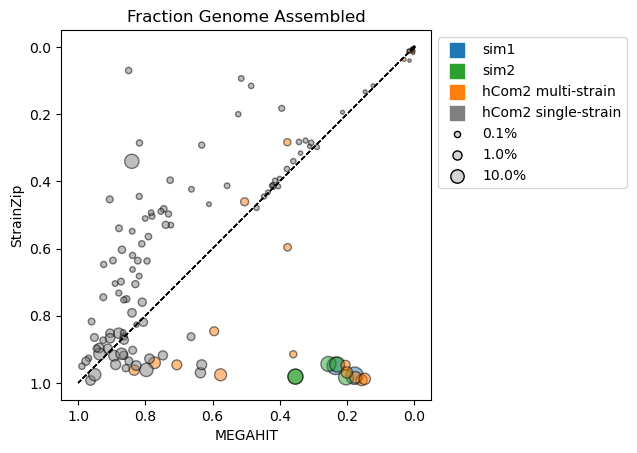

In [29]:
def _rabund_to_size(x):
    return np.cbrt(x) * 200

fig, ax = plt.subplots()


for d0, color in [
    (sim1_cvrg, 'tab:blue'),
    (sim2_cvrg, 'tab:green'),
    (hcom2_multi_cvrg, 'tab:orange'),
    (hcom2_single_cvrg, 'grey'),
]:
    d = d0.assign(s=lambda x: x.mean_rabund.pipe(_rabund_to_size))
        
    ax.scatter('megahit', 'strainzip', data=d, color=color, edgecolor='k', s='s', alpha=0.5, label='__nolegend__')
    ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
    ax.set_aspect(1)
    ax.set_xlabel('MEGAHIT')
    ax.set_ylabel('StrainZip')


ax.scatter([], [], color='tab:blue', marker='s', label='sim1', s=100)
ax.scatter([], [], color='tab:green', marker='s', label='sim2', s=100)
ax.scatter([], [], color='tab:orange', marker='s', label='hCom2 multi-strain', s=100)
ax.scatter([], [], color='grey', marker='s', label='hCom2 single-strain', s=100)


for _rabund in [0.001, 0.01, 0.1]:
    ax.scatter([], [], color='lightgrey', edgecolor='k', s=_rabund_to_size(_rabund), label=f'{_rabund:.01%}')
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title('Fraction Genome Assembled')
ax.invert_yaxis()
ax.invert_xaxis()

In [49]:
hcom2_single_err = pd.read_table('fig/normalized_absolute_error_id100_hcom2_singlestrain.tsv', index_col='genome_id')
hcom2_multi_err = pd.read_table('fig/normalized_absolute_error_id100_hcom2_multistrain.tsv', index_col='genome_id')
sim1_err = pd.read_table('fig/normalized_absolute_error_id100_sim1.tsv', index_col='genome_id')
sim2_err = pd.read_table('fig/normalized_absolute_error_id100_sim2.tsv', index_col='genome_id')

Text(0.5, 1.0, 'Fraction Genome Assembled')

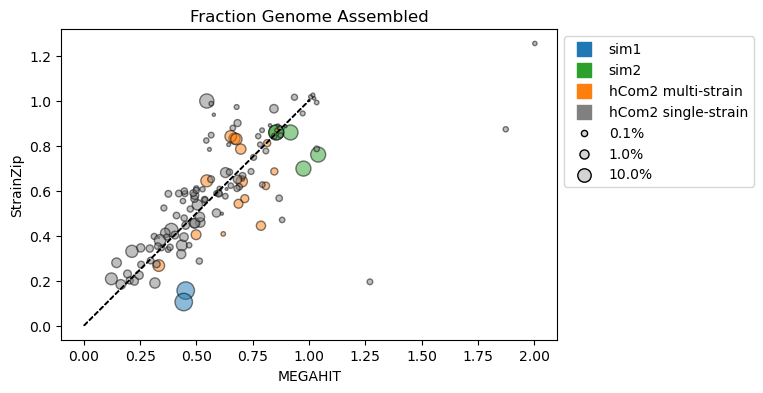

In [51]:
def _rabund_to_size(x):
    return np.cbrt(x) * 200

fig, ax = plt.subplots()


for d0, color in [
    (sim1_err, 'tab:blue'),
    (sim2_err, 'tab:green'),
    (hcom2_multi_err, 'tab:orange'),
    (hcom2_single_err, 'grey'),
]:
    d = d0.assign(s=lambda x: x.mean_rabund.pipe(_rabund_to_size))
        
    ax.scatter('megahit', 'strainzip', data=d, color=color, edgecolor='k', s='s', alpha=0.5, label='__nolegend__')
    ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
    ax.set_aspect(1)
    ax.set_xlabel('MEGAHIT')
    ax.set_ylabel('StrainZip')


ax.scatter([], [], color='tab:blue', marker='s', label='sim1', s=100)
ax.scatter([], [], color='tab:green', marker='s', label='sim2', s=100)
ax.scatter([], [], color='tab:orange', marker='s', label='hCom2 multi-strain', s=100)
ax.scatter([], [], color='grey', marker='s', label='hCom2 single-strain', s=100)


for _rabund in [0.001, 0.01, 0.1]:
    ax.scatter([], [], color='lightgrey', edgecolor='k', s=_rabund_to_size(_rabund), label=f'{_rabund:.01%}')
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title('Fraction Genome Assembled')

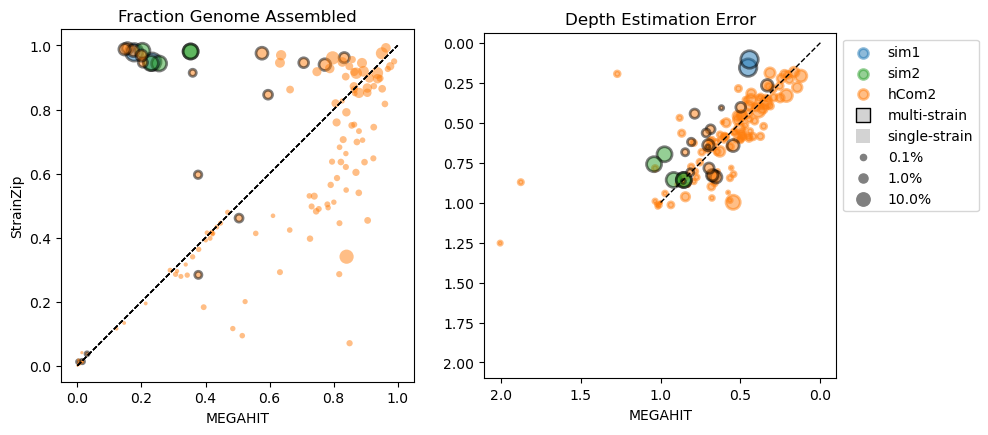

In [86]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
for d0, color, edgecolor in [
    (sim1_cvrg, 'tab:blue', 'k'),
    (sim2_cvrg, 'tab:green', 'k'),
    (hcom2_multi_cvrg, 'tab:orange', 'k'),
    (hcom2_single_cvrg, 'tab:orange', 'None'),
]:
    d = d0.assign(s=lambda x: x.mean_rabund.pipe(_rabund_to_size))
        
    ax.scatter('megahit', 'strainzip', data=d, color=color, edgecolor=edgecolor, lw=2, s='s', alpha=0.5, label='__nolegend__')
    ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')

ax.set_aspect(1)
ax.set_xlabel('MEGAHIT')
ax.set_ylabel('StrainZip')
ax.set_title('Fraction Genome Assembled')





ax = axs[1]
for label, d0, color, edgecolor in [
    ('__nolabel__', hcom2_single_err, 'tab:orange', None),
    ('sim1', sim1_err, 'tab:blue', 'k'),
    ('sim2', sim2_err, 'tab:green', 'k'),
    ('hCom2', hcom2_multi_err, 'tab:orange', 'k'),
]:
    d = d0.assign(s=lambda x: x.mean_rabund.pipe(_rabund_to_size))
        
    ax.scatter('megahit', 'strainzip', data=d, color=color, edgecolor=edgecolor, lw=2, s='s', alpha=0.5, label='__nolabel__')
    ax.scatter([], [], data=d, color=color, lw=2, s=50, alpha=0.5, label=label)


# ax.scatter([], [], color='tab:blue', marker='s', label='sim1', s=100)
# ax.scatter([], [], color='tab:green', marker='s', label='sim2', s=100)
# ax.scatter([], [], color='tab:orange', marker='s', label='hCom2 multi-strain', s=100)
# ax.scatter([], [], color='grey', marker='s', label='hCom2 single-strain', s=100)

ax.scatter([], [], color='lightgrey', marker='s', edgecolor='k', label='multi-strain', s=100)
ax.scatter([], [], color='lightgrey', marker='s', edgecolor='none', label='single-strain', s=100)

for _rabund in [0.001, 0.01, 0.1]:
    ax.scatter([], [], color='grey', s=_rabund_to_size(_rabund), label=f'{_rabund:.01%}')
ax.legend(bbox_to_anchor=(1, 1))

ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
ax.set_ylim(top=2.1)
ax.set_aspect(1)
ax.set_xlabel('MEGAHIT')
# ax.set_ylabel('StrainZip')
ax.set_title('Depth Estimation Error')
ax.invert_xaxis()
ax.invert_yaxis()